# Phase 2 qwen — 실험 결과 종합 분석

In [14]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──
nanum = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
noto  = [f.fname for f in fm.fontManager.ttflist if 'NotoSansCJK' in f.name or 'Noto Sans CJK' in f.name]

if nanum:
    plt.rcParams['font.family'] = 'NanumGothic'
elif noto:
    plt.rcParams['font.family'] = 'Noto Sans CJK KR'
else:
    print('⚠️ 한국어 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.')

plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..'))
RESULTS_ROOT  = os.path.join(PROJECT_ROOT, 'results', 'phase2_qwen')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS_ROOT : {RESULTS_ROOT}')

# ── 스타일 설정 ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── 상수 ──
DATASETS = ['humaneval_fin']
# METHODS  = ['single', 'retry', 'repair','code_then_plan','code_then_plan_repair','policy_loop']
METHODS  = ['single','repair','code_then_plan','code_then_plan_repair','rpe_policy','rpe_policy_v2']
METHOD_LABELS = {
    'single'   : 'Single Shot',
    'repair'   : 'Repair Loop',
    'planner_coder' : 'Planner-Coder',
    'code_then_plan' : 'Code-Then-Plan',
    'code_then_replan' : 'Code-Then-Replan',
    'code_then_plan_repair' : 'Code-Then-Plan+Repair',
    'rpe_policy' : 'Policy Loop',
    'rpe_policy_v2': 'Policy Loop v2'
}

# ── 색상 팔레트 ──
METHOD_COLORS = {
    'single'        : '#4C72B0',
    'repair'       : '#55A868',
    'planner_coder'        : '#C44E52',
    'code_then_plan' : '#8172B2',
    'code_then_replan' : '#9EDDFF',
    'code_then_plan_repair' : '#DD8452',
    'rpe_policy' : '#FFA500',
    'rpe_policy_v2': '#FF6347'
}

PROJECT_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration
RESULTS_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration/results/phase2_qwen


---
## 1. 데이터 로드

In [15]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# ── 결과 로드 ──
summaries          = {}   # (dataset, method) -> summary dict
analyses           = {}   # (dataset, method) -> analysis dict
step_logs_all      = {}   # (dataset, method) -> list of step records
traj_logs_all      = {}   # (dataset, method) -> list of trajectory records
failure_examples_all = {} # (dataset, method) -> dict of failure examples

found = []
missing = []

for dataset in DATASETS:
    for method in METHODS:
        base = os.path.join(RESULTS_ROOT, dataset, method)
        summary_path = os.path.join(base, 'summary.json')
        if os.path.exists(summary_path):
            key = (dataset, method)
            summaries[key]     = load_json(summary_path)
            # analyses[key]      = load_json(os.path.join(base, 'analysis.json'))
            step_logs_all[key] = load_jsonl(os.path.join(base, 'step_logs.jsonl'))
            traj_logs_all[key] = load_jsonl(os.path.join(base, 'trajectory_logs.jsonl'))
            
            fe_path = os.path.join(base, 'failure_examples.json')
            if os.path.exists(fe_path):
                failure_examples_all[key] = load_json(fe_path)
            
            found.append(f'{dataset}/{method}')
        else:
            missing.append(f'{dataset}/{method}')

print(f'✅ 로드 성공 ({len(found)}개):', ', '.join(found))
if missing:
    print(f'⚠️  결과 없음 ({len(missing)}개):', ', '.join(missing))

✅ 로드 성공 (6개): humaneval_fin/single, humaneval_fin/repair, humaneval_fin/code_then_plan, humaneval_fin/code_then_plan_repair, humaneval_fin/rpe_policy, humaneval_fin/rpe_policy_v2


---
## 2-1. 핵심 지표 비교 (pass@1, exec_success_rate, conditional_pass)

In [16]:
# ── summary DataFrame 구성 ──
rows = []

for (dataset, method), s in summaries.items():
    if s is None:
        continue

    max_calls = s.get("max_calls", 10)
    success_key = s.get("success_metric_name", f"success@{max_calls}")

    row = {
        "dataset": dataset,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),

        "total": s.get("total_problems", s.get("total", 0)),

        # 기존 num_pass/pass@1 대신 success 계열 사용
        "num_success": s.get("num_success", s.get("success", s.get("num_pass", s.get("passed", 0)))),

        "success_metric_name": success_key,
        "success@k": s.get(
            "success_at_k",
            s.get(success_key, s.get("pass_at_1", s.get("pass@1", 0.0)))
        ),

        "execution_success_rate": s.get("execution_success_rate", 0.0),

        # 기존 conditional_pass와 새 conditional_success 둘 다 대응
        "conditional_success": s.get(
            "conditional_success",
            s.get("conditional_pass", 0.0)
        ),

        "avg_tokens": s.get("avg_tokens", 0.0),
        "avg_latency": s.get("avg_latency", 0.0),
        "avg_calls": s.get("avg_calls", 0.0),
    }

    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(["dataset", "method"])

# 방법 순서 고정
method_order = [
    m for m in METHODS
    if m in df_summary.index.get_level_values("method").unique()
]

print("\n=== Summary DataFrame ===")
display(
    df_summary[
        [
            "total",
            "num_success",
            "success_metric_name",
            "success@k",
            "execution_success_rate",
            "conditional_success",
            "avg_tokens",
            "avg_latency",
            "avg_calls",
        ]
    ].round(4)
)


=== Summary DataFrame ===


total  num_success success_metric_name  \
dataset       method                                                          
humaneval_fin single                   164          114           success@1   
              repair                   164          140          success@10   
              code_then_plan           164          150          success@10   
              code_then_plan_repair    164          151          success@10   
              rpe_policy               164          154          success@10   
              rpe_policy_v2            164          151          success@10   

                                     success@k  execution_success_rate  \
dataset       method                                                     
humaneval_fin single                    0.6951                  0.8476   
              repair                    0.8537                  0.8902   
              code_then_plan            0.9146                  0.9939   
              code_then_plan_repair     0.9207                  0.9573   
              rpe_policy                0.9390                  0.9817   
              rpe_policy_v2             0.9207                  0.9939   

                                     conditional_success  avg_tokens  \
dataset       method                                                   
humaneval_fin single                              0.8201    310.6768   
              repair                              0.9589   1841.0671   
              code_then_plan                      0.9202    735.6524   
              code_then_plan_repair               0.9618    908.7988   
              rpe_policy                          0.9565      0.0000   
              rpe_policy_v2                       0.9264      0.0000   

                                     avg_latency  avg_calls  
dataset       method                                         
humaneval_fin single                      2.4059     1.0000  
              repair                      8.0875     2.7073  
              code_then_plan              3.5982     2.2439  
              code_then_plan_repair       4.2419     2.5061  
              rpe_policy                  0.0000     0.0000  
              rpe_policy_v2               0.0000     0.0000

## 2-2. 토큰 비교

In [17]:
# ── method x stage별 call-level token stats ──
stage_token_rows = []

for dataset in DATASETS:
    for method in METHODS:
        key = (dataset, method)
        steps = pd.DataFrame(step_logs_all.get(key, []))

        if steps.empty or 'stage' not in steps.columns:
            continue

        for stage, g in steps.groupby('stage'):
            stage_token_rows.append({
                'dataset': dataset,
                'method': method,
                'method_label': METHOD_LABELS.get(method, method),
                'stage': stage,
                'num_calls': len(g),

                'input_min': g['input_tokens'].min(),
                'input_avg': g['input_tokens'].mean(),
                'input_max': g['input_tokens'].max(),

                'output_min': g['output_tokens'].min(),
                'output_avg': g['output_tokens'].mean(),
                'output_max': g['output_tokens'].max(),

                'total_min': g['total_tokens'].min(),
                'total_avg': g['total_tokens'].mean(),
                'total_max': g['total_tokens'].max(),
            })

df_stage_token_stats = pd.DataFrame(stage_token_rows)
df_stage_token_stats = df_stage_token_stats.set_index(['dataset', 'method', 'stage'])

display(df_stage_token_stats[
    [
        'num_calls',
        'input_min', 'input_avg', 'input_max',
        'output_min', 'output_avg', 'output_max',
        'total_min', 'total_avg', 'total_max',
    ]
].round(2))

num_calls  input_min  \
dataset       method                stage                             
humaneval_fin single                generate         164         38   
              repair                generate         164         38   
                                    repair           280        233   
              code_then_plan        generate         164         38   
                                    plan             102        116   
                                    plan_code        102        183   
              code_then_plan_repair generate         164         38   
                                    plan              96        116   
                                    plan_code         96        183   
                                    repair            55        267   
              rpe_policy            generate         164         38   
                                    plan              68        116   
                                    plan_code         68        183   
                                    repair            70        257   
              rpe_policy_v2         generate         164         38   
                                    plan              48        116   
                                    plan_code         81        210   
                                    repair            24        384   
                                    replan            33        384   

                                               input_avg  input_max  \
dataset       method                stage                             
humaneval_fin single                generate      134.09        391   
              repair                generate      134.09        391   
                                    repair        653.86       1305   
              code_then_plan        generate      134.09        391   
                                    plan          225.54        468   
                                    plan_code     325.50        661   
              code_then_plan_repair generate      134.09        391   
                                    plan          225.04        468   
                                    plan_code     319.10        608   
                                    repair        449.24        941   
              rpe_policy            generate      134.09        391   
                                    plan          363.97       1030   
                                    plan_code     335.18        614   
                                    repair        609.56       1143   
              rpe_policy_v2         generate      134.09        391   
                                    plan          215.85        468   
                                    plan_code     322.78        571   
                                    repair        633.29        925   
                                    replan        569.67       1260   

                                               output_min  output_avg  \
dataset       method                stage                               
humaneval_fin single                generate           14      176.59   
              repair                generate           14      166.55   
                                    repair              4      248.38   
              code_then_plan        generate           14      160.88   
                                    plan               17       66.95   
                                    plan_code          18       90.55   
              code_then_plan_repair generate           14      166.53   
                                    plan               22       61.04   
                                    plan_code          18       88.24   
                                    repair              3      153.89   
              rpe_policy            generate           14      168.84   
                                    plan               17       68.54   
                                    plan_

In [18]:
display(
    df_stage_token_stats.loc[('humaneval_fin', 'rpe_policy')]
    .round(2)
)

# generate   : 초기 single-shot 비용
# plan       : planner prompt 비용
# plan_code  : plan-conditioned coding 비용
# replan     : failure-aware planning 비용
# replan_code: revised-plan coding 비용
# repair     : feedback-based repair 비용

,method_label,num_calls,input_min,input_avg,input_max,output_min,output_avg,output_max,total_min,total_avg,total_max
stage,,,,,,,,,,,
generate,Policy Loop,164,38,134.09,391,14,168.84,512,63,302.93,716
plan,Policy Loop,68,116,363.97,1030,17,68.54,179,150,432.51,1123
plan_code,Policy Loop,68,183,335.18,614,21,96.38,352,257,431.56,950
repair,Policy Loop,70,257,609.56,1143,3,250.89,512,266,860.44,1617


---
## 3. 방법별 비교 시각화

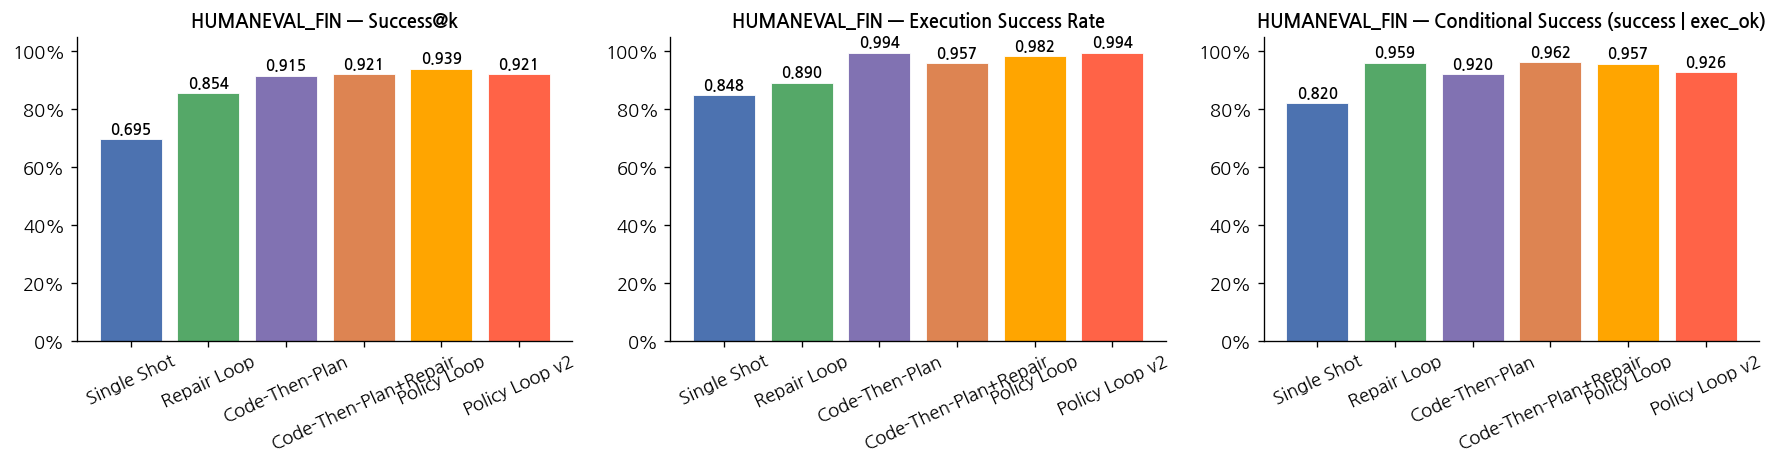

In [19]:
rows = []

for (dataset, method), s in summaries.items():
    if s is None:
        continue

    max_calls = s.get("max_calls", 10)
    success_key = s.get("success_metric_name", f"success@{max_calls}")

    success_k = s.get(
        "success_at_k",
        s.get(success_key, s.get("success@k", s.get("pass_at_1", s.get("pass@1", 0.0))))
    )

    rows.append({
        "dataset": dataset,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),
        "total": s.get("total_problems", s.get("total", 0)),
        "success": s.get("num_success", s.get("success", s.get("num_pass", s.get("passed", 0)))),
        "success_metric_name": success_key,
        "success@k": success_k,
        "execution_success_rate": s.get("execution_success_rate", 0.0),
        "conditional_success": s.get("conditional_success", s.get("conditional_pass", 0.0)),
        "avg_tokens": s.get("avg_tokens", 0.0),
        "avg_latency": s.get("avg_latency", 0.0),
        "avg_calls": s.get("avg_calls", 0.0),
    })

df_summary = pd.DataFrame(rows)

metrics_to_plot = [
    "success@k",
    "execution_success_rate",
    "conditional_success",
]

metric_titles = {
    "success@k": "Success@k",
    "execution_success_rate": "Execution Success Rate",
    "conditional_success": "Conditional Success (success | exec_ok)",
}

available_datasets = [
    d for d in DATASETS
    if any((d, m) in summaries for m in METHODS)
]

fig, axes = plt.subplots(
    len(available_datasets),
    len(metrics_to_plot),
    figsize=(5 * len(metrics_to_plot), 4 * len(available_datasets)),
    squeeze=False,
)

for row_idx, dataset in enumerate(available_datasets):
    df_ds = df_summary[df_summary["dataset"] == dataset].copy()
    if df_ds.empty:
        continue

    method_order = [m for m in METHODS if m in df_ds["method"].values]
    df_ds = df_ds.set_index("method").reindex(method_order).reset_index()

    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        colors = [METHOD_COLORS.get(m, "#999999") for m in df_ds["method"]]

        bars = ax.bar(
            df_ds["method_label"],
            df_ds[metric],
            color=colors,
            edgecolor="white",
            linewidth=0.5,
        )

        for bar, val in zip(bars, df_ds[metric]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

        ax.set_title(
            f"{dataset.upper()} — {metric_titles[metric]}",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
# plt.savefig(os.path.join(NOTEBOOK_DIR, "ver4_metrics_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
# print("📊 ver4_metrics_comparison.png 저장 완료")

---
## 4. Failure Type 분석

In [20]:
# 4-1. failure_type_counts (analysis.json)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'📌 {dataset.upper()} — Failure Type Counts')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ftc = analyses[key].get('failure_type_counts', {})
        if not ftc:
            print(f'  {METHOD_LABELS[method]}: (failure 없음)')
            continue
        print(f'\n  {METHOD_LABELS[method]}:')
        for ftype, count in sorted(ftc.items(), key=lambda x: -x[1]):
            print(f'    {ftype}: {count}')


📌 HUMANEVAL_FIN — Failure Type Counts


In [21]:
# 4-2. failure_family_counts (analysis.json)
print('\n' + '=' * 60)
print('📌 Failure Family Counts (coarse-grained)')
print('=' * 60)

family_rows = []
for (dataset, method), a in analyses.items():
    ffc = a.get('failure_family_counts', {})
    for family, count in ffc.items():
        family_rows.append({
            'dataset': dataset,
            'method': METHOD_LABELS.get(method, method),
            'failure_family': family,
            'count': count,
        })

if family_rows:
    df_family = pd.DataFrame(family_rows)
    pivot_family = df_family.pivot_table(
        index=['dataset', 'method'], columns='failure_family',
        values='count', fill_value=0, aggfunc='sum'
    )
    display(pivot_family)
else:
    print('  (failure_family_counts 데이터 없음)')


📌 Failure Family Counts (coarse-grained)
  (failure_family_counts 데이터 없음)


In [22]:
# 4-3. Failure Family 시각화 (Stacked Bar)
for dataset in available_datasets:
    family_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ffc = analyses[key].get('failure_family_counts', {})
        if ffc:
            family_data[METHOD_LABELS[method]] = ffc
    
    if not family_data:
        continue
    
    df_fam = pd.DataFrame(family_data).T.fillna(0)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    df_fam.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{dataset.upper()} — Failure Family 분포', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Failure Family', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 5. Transition Path 분석 (repair / code_then_plan / code_then_replan / code_then_plan_repair / rpe)

In [23]:
# Transition Path 분석 (retry / repair / planner_coder)
# 5-1. Transition Sequences (step) 테이블

def extract_sequence_counts(traj_logs, max_len=10, drop_after_pass=True):
    seq_counts = {}

    for traj in traj_logs:
        path = traj.get('transition_path', [])

        # coarse: status만 사용
        # coarse_path = [p.split(':')[0] for p in path]
        coarse_path = path  # 그대로 사용

        # 🔥 PASS 이후 제거
        if drop_after_pass and 'PASS' in coarse_path:
            idx = coarse_path.index('PASS')
            coarse_path = coarse_path[:idx+1]

        # 길이별로 모두 수집 (중요)
        for L in range(2, min(max_len, len(coarse_path)) + 1):
            for i in range(len(coarse_path) - L + 1):
                seq = tuple(coarse_path[i:i+L])
                seq_counts[seq] = seq_counts.get(seq, 0) + 1

    return seq_counts

def normalize_seq_counts(seq_counts):
    total = sum(seq_counts.values())
    return {k: v / total for k, v in seq_counts.items()}

def print_top_sequences(seq_counts, top_k=10):
    sorted_items = sorted(seq_counts.items(), key=lambda x: -x[1])[:top_k]

    for seq, val in sorted_items:
        seq_str = ' -> '.join(seq)
        print(f'    {seq_str}: {val:.3f}')

In [24]:
for dataset in DATASETS:
    print(f'\n{"=" * 60}')
    print(f'🔄 {dataset.upper()} — Transition Sequences')
    print('=' * 60)

    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue

        traj_logs = traj_logs_all[key]

        seq_counts = extract_sequence_counts(traj_logs, max_len=20)
        if not seq_counts:
            continue

        seq_ratio = normalize_seq_counts(seq_counts)

        print(f'\n  {METHOD_LABELS.get(method, method)}:')
        print_top_sequences(seq_ratio, top_k=10)


🔄 HUMANEVAL_FIN — Transition Sequences

  Repair Loop:
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.089
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.070
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.056
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.044
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.034
    TEST_FAIL:AssertionError -> TEST_FAIL:AssertionError: 0.029
    EXEC_FAIL:SyntaxError -> EXEC_FAIL:SyntaxError: 0.025
    EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError -> EXEC_FAIL:NameError: 0.023
    TEST_FAIL:AssertionError -> TEST_FAIL:AssertionError -> TEST_FAIL:AssertionError: 0.018
    TEST_FAIL:AssertionError -> TEST_FAIL:AssertionError -> T

In [25]:
def count_total_subsequences(traj_logs, max_len=20):
    total = 0

    for traj in traj_logs:
        path = traj.get('transition_path', [])

        n = len(path)
        if n < 2:
            continue

        for L in range(2, min(n, max_len) + 1):
            total += (n - L + 1)

    return total

total = count_total_subsequences(traj_logs_all[('humaneval_fin','repair')])
print(total)

1251


### Failure breakdown

In [26]:
# ============================================================
# Failure Breakdown by final_status / failure_family
# ============================================================

breakdown_rows = []

def coarse_fail(status):
    if status == "PASS":
        return "PASS"
    return str(status).split(":")[0]

for (dataset, method), trajs in traj_logs_all.items():
    total = len(trajs)

    counts = {
        "PASS": 0,
        "CODE_FAIL": 0,
        "EXEC_FAIL": 0,
        "TEST_FAIL": 0,
        "OTHER_FAIL": 0,
    }

    for t in trajs:
        status = t.get("final_status", "")
        family = t.get("failure_family") or coarse_fail(status)

        if family in counts:
            counts[family] += 1
        else:
            counts["OTHER_FAIL"] += 1

    row = {
        "dataset": dataset,
        "method": method,
        "method_label": METHOD_LABELS.get(method, method),
        "total": total,
        **counts,
    }

    for k in counts:
        row[f"{k}_rate"] = counts[k] / total if total > 0 else 0.0

    breakdown_rows.append(row)

df_failure_breakdown = pd.DataFrame(breakdown_rows)

# method 순서 정렬
df_failure_breakdown["method"] = pd.Categorical(
    df_failure_breakdown["method"],
    categories=METHODS,
    ordered=True,
)
df_failure_breakdown = df_failure_breakdown.sort_values(["dataset", "method"])

print("\n=== Failure Breakdown ===")
display(
    df_failure_breakdown[
        [
            "dataset",
            "method_label",
            "total",
            "PASS",
            "CODE_FAIL",
            "EXEC_FAIL",
            "TEST_FAIL",
            "OTHER_FAIL",
            "PASS_rate",
            "CODE_FAIL_rate",
            "EXEC_FAIL_rate",
            "TEST_FAIL_rate",
        ]
    ].round(4)
)


=== Failure Breakdown ===


,dataset,method_label,total,PASS,CODE_FAIL,EXEC_FAIL,TEST_FAIL,OTHER_FAIL,PASS_rate,CODE_FAIL_rate,EXEC_FAIL_rate,TEST_FAIL_rate
0,humaneval_fin,Single Shot,164,114,0,25,25,0,0.6951,0.0,0.1524,0.1524
1,humaneval_fin,Repair Loop,164,140,0,18,6,0,0.8537,0.0,0.1098,0.0366
2,humaneval_fin,Code-Then-Plan,164,150,0,1,13,0,0.9146,0.0,0.0061,0.0793
3,humaneval_fin,Code-Then-Plan+Repair,164,151,0,7,6,0,0.9207,0.0,0.0427,0.0366
4,humaneval_fin,Policy Loop,164,154,0,3,7,0,0.9390,0.0,0.0183,0.0427
5,humaneval_fin,Policy Loop v2,164,151,0,1,12,0,0.9207,0.0,0.0061,0.0732
